# Part A - Alternative Pipeline 1: Plane Fitting

**Target file:** `Helicene_Ag(111)008.sxm`

This notebook implements only the first alternative preprocessing method defined in the Part A workflow:

```text
2D plane fitting and subtraction
-> Gaussian filtering
-> global Otsu thresholding
-> closing
-> hole filling
-> small-object removal
-> border-object removal
-> connected-component labelling
```

The purpose is to convert the complete STM height image into candidate molecular objects and diagnostic outputs. It does **not** classify candidates as Dimer, Trimer, Tetramer, P2, or P3. The connected-component count produced here is an **unvalidated candidate count**, not a ground-truth molecule count.

## 1. Environment and fixed configuration

This Cell imports the packages used by the pipeline and defines all experimental parameters in one place. Keeping parameters together makes later sensitivity analysis reproducible and prevents hidden settings from being scattered through the notebook.

Initial settings follow the approved design:

- Gaussian standard deviation: 1 pixel;
- closing footprint: disk with radius 1 pixel;
- minimum retained connected-region area: 50 pixels;
- eight-connected foreground labelling.

In [1]:
import logging
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.ndimage import binary_fill_holes

# Compatibility only: nanonispy still uses NumPy aliases removed in NumPy 2.x.
if not hasattr(np, "float"):
    np.float = float
if not hasattr(np, "int"):
    np.int = int

import nanonispy as nap

from skimage import measure
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import closing, disk, remove_small_objects
from skimage.segmentation import clear_border

%matplotlib inline

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams["figure.dpi"] = 120

GAUSSIAN_SIGMA = 1.0
CLOSING_RADIUS = 1
MIN_OBJECT_AREA = 50
CONNECTIVITY = 2

print("Alternative 1 configuration")
print(f"  Gaussian sigma: {GAUSSIAN_SIGMA} pixel")
print(f"  Closing radius: {CLOSING_RADIUS} pixel")
print(f"  Minimum area: {MIN_OBJECT_AREA} pixels")
print(f"  Connectivity: {CONNECTIVITY} (8-connected)")

Alternative 1 configuration
  Gaussian sigma: 1.0 pixel
  Closing radius: 1 pixel
  Minimum area: 50 pixels
  Connectivity: 2 (8-connected)


## 2. Locate and read the raw SXM data

The notebook searches upward from its working directory for the `CountingMolecules` project root. This avoids a computer-specific absolute input path while still failing clearly if the required file is absent.

The common preparation is the same for every future Part A method:

1. read the `Z/forward` STM height channel;
2. flip the array once when the recorded scan direction is `down`;
3. replace any NaN or infinite values with the mean of valid pixels;
4. preserve an unchanged prepared raw-height copy;
5. extract scan range and physical pixel scale.

The colour map used for display is only a visualisation. The algorithm operates on the numerical height matrix.

In [2]:
TARGET_SUFFIX = Path(
    "ProjectData/Stetsovych Helicene/Helicene_Ag(111)008.sxm"
)


def locate_project_and_data(start=None):
    # Return the CountingMolecules root and target SXM path.
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate_root in (start, *start.parents):
        candidate_file = candidate_root / TARGET_SUFFIX
        if candidate_file.is_file():
            return candidate_root, candidate_file
    raise FileNotFoundError(
        f"Could not find {TARGET_SUFFIX} from {start} or any parent directory."
    )


def read_prepared_sxm(path):
    # Read Z/forward and apply only the shared orientation/invalid-value fixes.
    scan = nap.read.Scan(str(path))
    image = np.asarray(scan.signals["Z"]["forward"], dtype=float).copy()
    scan_direction = str(scan.header.get("scan_dir", "")).lower()

    if scan_direction == "down":
        image = np.flipud(image)

    invalid_mask = ~np.isfinite(image)
    invalid_count = int(invalid_mask.sum())
    if invalid_count:
        finite_mean = float(image[~invalid_mask].mean())
        image[invalid_mask] = finite_mean

    scan_pixels = np.asarray(
        scan.header.get("scan_pixels", image.shape[::-1]), dtype=float
    )
    scan_range = np.asarray(
        scan.header.get("scan_range", [np.nan, np.nan]), dtype=float
    )
    pixel_scale = scan_range / scan_pixels

    metadata = {
        "scan_direction": scan_direction,
        "scan_pixels": scan_pixels,
        "scan_range_m": scan_range,
        "pixel_scale_m": pixel_scale,
        "invalid_pixels_replaced": invalid_count,
    }
    return image, metadata


PROJECT_ROOT, DATA_FILE = locate_project_and_data()
OUTPUT_DIR = (
    PROJECT_ROOT / "project" / "P1" / "outputs" /
    "alternative_1_plane_fitting"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

prepared_height, metadata = read_prepared_sxm(DATA_FILE)
raw_height = prepared_height.copy()

assert raw_height.ndim == 2
assert np.isfinite(raw_height).all()

print(f"Project root: {PROJECT_ROOT}")
print(f"Input file: {DATA_FILE}")
print(f"Image shape: {raw_height.shape}")
print(f"Original scan direction: {metadata['scan_direction']}")
print(f"Scan range: {metadata['scan_range_m']} metres")
print(f"Pixel scale: {metadata['pixel_scale_m']} metres/pixel")
print(f"Invalid pixels replaced: {metadata['invalid_pixels_replaced']}")
print(
    "Prepared height range: "
    f"{raw_height.min():.6e} to {raw_height.max():.6e} metres"
)

Project root: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules
Input file: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/ProjectData/Stetsovych Helicene/Helicene_Ag(111)008.sxm
Image shape: (1024, 1024)
Original scan direction: down
Scan range: [8.e-08 8.e-08] metres
Pixel scale: [7.8125e-11 7.8125e-11] metres/pixel
Invalid pixels replaced: 0
Prepared height range: -8.249751e-09 to -7.999142e-09 metres


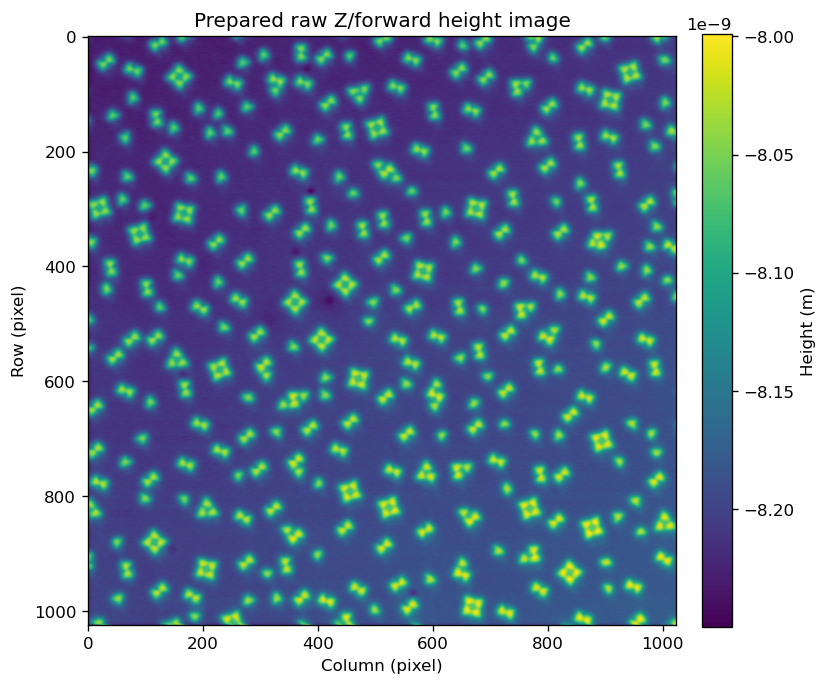

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
image = ax.imshow(raw_height, cmap="viridis", origin="upper")
ax.set_title("Prepared raw Z/forward height image")
ax.set_xlabel("Column (pixel)")
ax.set_ylabel("Row (pixel)")
fig.colorbar(image, ax=ax, label="Height (m)", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 3. Two-dimensional plane fitting and subtraction

**Step 3 uses least-squares fitting to estimate and subtract a two-dimensional background plane from the STM image, removing global tilt while preserving local molecular height features.**

### Matrix representation of the plane

For an image containing $H$ rows and $W$ columns, the total number of pixels is

$$
N = H \times W.
$$

For the $i$-th pixel, the plane model can be written as

$$
z_i = ax_i + by_i + c,
$$

where:

- $x_i$ is the column coordinate of the pixel;
- $y_i$ is the row coordinate of the pixel;
- $z_i$ is the measured STM height;
- $a$ is the background slope along the horizontal direction;
- $b$ is the background slope along the vertical direction;
- $c$ is the intercept, representing the general height level of the plane.

All pixel equations can be combined into one matrix equation:

$$
\mathbf{z} = X\boldsymbol{\beta},
$$

where

$$
\mathbf{z} =
\begin{bmatrix}
z_1 \\
z_2 \\
\vdots \\
z_N
\end{bmatrix},
\qquad
\boldsymbol{\beta} =
\begin{bmatrix}
a \\
b \\
c
\end{bmatrix},
$$

and

$$
X =
\begin{bmatrix}
x_1 & y_1 & 1 \\
x_2 & y_2 & 1 \\
\vdots & \vdots & \vdots \\
x_N & y_N & 1
\end{bmatrix}.
$$

The matrix $X$ is called the **design matrix**. Each row represents one
pixel. The first column stores the horizontal coordinate $x_i$, the second
column stores the vertical coordinate $y_i$, and the final column contains
ones so that the intercept $c$ can be included.

Multiplying $X$ by $\boldsymbol{\beta}$ produces the background height
predicted by the plane at every pixel:

$$
X\boldsymbol{\beta} =
\begin{bmatrix}
ax_1 + by_1 + c \\
ax_2 + by_2 + c \\
\vdots \\
ax_N + by_N + c
\end{bmatrix}.
$$

### Why least squares is required

A real STM image does not consist only of a perfect plane. It also contains
molecular structures, measurement noise, and other local height variations.
Therefore, it is generally impossible to find one plane that passes exactly
through every measured pixel.

For the $i$-th pixel, the fitting residual is

$$
e_i = ax_i + by_i + c - z_i.
$$

The least-squares method finds the values of $a$, $b$, and $c$ that minimise
the sum of all squared residuals:

$$
\hat{\boldsymbol{\beta}}
=
\arg\min_{\boldsymbol{\beta}}
\left\|X\boldsymbol{\beta}-\mathbf{z}\right\|_2^2.
$$

Equivalently,

$$
\hat{\boldsymbol{\beta}}
=
\arg\min_{a,b,c}
\sum_{i=1}^{N}
\left(ax_i+by_i+c-z_i\right)^2.
$$

Here, $\arg\min$ means “the parameter values that make the expression as
small as possible”. Squaring the residuals prevents positive and negative
errors from cancelling each other and gives a larger penalty to large fitting
errors.

The theoretical least-squares solution satisfies the normal equation:

$$
X^T X\hat{\boldsymbol{\beta}} = X^T\mathbf{z}.
$$

It is sometimes written as

$$
\hat{\boldsymbol{\beta}}
=
(X^T X)^{-1}X^T\mathbf{z}.
$$

However, `np.linalg.lstsq` uses a more numerically stable calculation rather
than explicitly computing the matrix inverse.

### Connection to the Python implementation

The pixel-coordinate arrays are created using:

```python
y, x = np.indices((rows, cols), dtype=float)
```

The two-dimensional coordinate arrays are flattened and combined to construct
the design matrix:

```python
design = np.column_stack(
    (x.ravel(), y.ravel(), np.ones(rows * cols, dtype=float))
)
```

Therefore, `design` corresponds to $X$, while `image.ravel()` corresponds to
the measured-height vector $\mathbf{z}$.

The coefficients are estimated using:

```python
coefficients, _, _, _ = np.linalg.lstsq(
    design, image.ravel(), rcond=None
)
```

The returned coefficient vector is

$$
\texttt{coefficients}
=
\begin{bmatrix}
\hat a \\
\hat b \\
\hat c
\end{bmatrix}.
$$

The fitted background plane is then reconstructed:

```python
fitted = (design @ coefficients).reshape(image.shape)
```

Mathematically,

$$
P(x,y)=\hat a x+\hat b y+\hat c.
$$

Finally, the fitted plane is subtracted from the prepared STM image:

```python
corrected = image - fitted
```

Therefore, the plane-corrected image is

$$
R(x,y)=I(x,y)-P(x,y).
$$

The large-scale linear background is represented by $P(x,y)$ and removed,
while local deviations remain in $R(x,y)$. Molecular structures should
therefore remain as local positive height features.

### Interpretation of the fitted coefficients

The fitted parameters have the following meanings:

- $\hat a>0$: the fitted background rises from left to right;
- $\hat a<0$: the fitted background falls from left to right;
- $\hat b>0$: the fitted background rises from top to bottom;
- $\hat b<0$: the fitted background falls from top to bottom;
- $\hat c$: the fitted background height at the coordinate origin.

For this image, the fitted coefficients are approximately

$$
\hat a = 2.147357\times10^{-14}\ \text{m/pixel},
$$

$$
\hat b = 3.345885\times10^{-14}\ \text{m/pixel},
$$

and

$$
\hat c = -8.207271\times10^{-9}\ \text{m}.
$$

Both slopes are positive, indicating that the fitted background increases
slightly along both image directions.

After plane subtraction, the mean residual height is approximately

$$
\overline{R}
\approx
-3.40\times10^{-22}\ \text{m}
\approx 0.
$$

This near-zero mean indicates that the overall linear background level has
been centred. It does not mean that the molecular height features have
disappeared.

### Limitation of the method

Plane fitting removes only a global linear background of the form

$$
P(x,y)=ax+by+c.
$$

It cannot fully remove curved backgrounds, local drift, or individual
row-by-row scanning artefacts. In addition, because every pixel is included
in the least-squares calculation, bright molecular pixels can slightly
influence the estimated plane.

Therefore, the resulting segmentation must still be compared with the
manually labelled reference before the method can be considered accurate.

In [4]:
def fit_and_subtract_plane(image):
    # Fit z = a*x + b*y + c and return plane, residual, and coefficients.
    rows, cols = image.shape
    y, x = np.indices((rows, cols), dtype=float)
    design = np.column_stack(
        (x.ravel(), y.ravel(), np.ones(rows * cols, dtype=float))
    )
    coefficients, _, _, _ = np.linalg.lstsq(
        design, image.ravel(), rcond=None
    )
    fitted = (design @ coefficients).reshape(image.shape)
    corrected = image - fitted
    return fitted, corrected, coefficients


fitted_plane, plane_corrected, plane_coefficients = fit_and_subtract_plane(
    raw_height
)
plane_a, plane_b, plane_c = plane_coefficients

assert fitted_plane.shape == raw_height.shape
assert plane_corrected.shape == raw_height.shape
assert np.isfinite(fitted_plane).all()
assert np.isfinite(plane_corrected).all()
assert abs(float(plane_corrected.mean())) < 1e-15

print("Fitted plane: z = a*x + b*y + c")
print(f"  a (column slope): {plane_a:.6e} m/pixel")
print(f"  b (row slope):    {plane_b:.6e} m/pixel")
print(f"  c (intercept):    {plane_c:.6e} m")
print(f"Corrected image mean: {plane_corrected.mean():.6e} m")
print(
    "Corrected height range: "
    f"{plane_corrected.min():.6e} to {plane_corrected.max():.6e} metres"
)

Fitted plane: z = a*x + b*y + c
  a (column slope): 2.147357e-14 m/pixel
  b (row slope):    3.345885e-14 m/pixel
  c (intercept):    -8.207271e-09 m
Corrected image mean: -3.401554e-22 m
Corrected height range: -6.396565e-11 to 1.674372e-10 metres


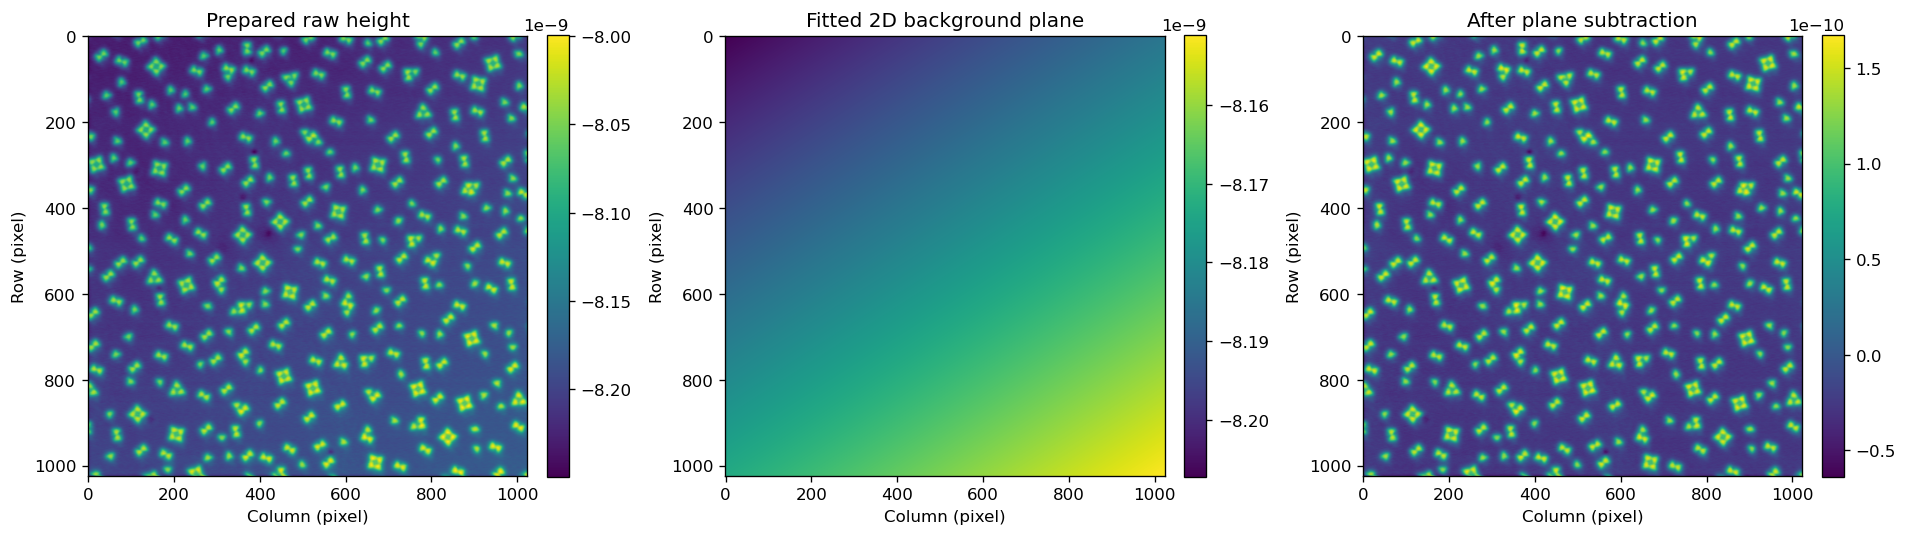

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

raw_plot = axes[0].imshow(raw_height, cmap="viridis", origin="upper")
axes[0].set_title("Prepared raw height")
fig.colorbar(raw_plot, ax=axes[0], fraction=0.046, pad=0.04)

plane_plot = axes[1].imshow(fitted_plane, cmap="viridis", origin="upper")
axes[1].set_title("Fitted 2D background plane")
fig.colorbar(plane_plot, ax=axes[1], fraction=0.046, pad=0.04)

corrected_plot = axes[2].imshow(
    plane_corrected, cmap="viridis", origin="upper"
)
axes[2].set_title("After plane subtraction")
fig.colorbar(corrected_plot, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("Column (pixel)")
    ax.set_ylabel("Row (pixel)")

plt.tight_layout()
plt.show()

## 4. Gaussian filtering and global Otsu thresholding

**Gaussian filtering first smooths the image and reduces high-frequency noise, making molecular regions more continuous. Otsu thresholding then automatically selects a global threshold to separate candidate molecular regions from the background. The purpose is to generate an initial binary mask for subsequent morphological cleaning and molecule counting.**


First, Gaussian filtering is applied:

$$
G_{\sigma}(x,y)
=
\frac{1}{2\pi\sigma^2}
\exp\left(
-\frac{x^2+y^2}{2\sigma^2}
\right)
$$

$$
F=G_{\sigma}*R
$$

Here, $\sigma=1$ pixel. Each output pixel is calculated as a weighted average of its neighbouring pixels, with closer pixels receiving greater weights. This suppresses high-frequency noise and makes the molecular regions smoother and more continuous.

Global Otsu thresholding is then applied:

$$
T^*
=
\arg\max_T
\omega_0(T)\omega_1(T)
\left[\mu_0(T)-\mu_1(T)\right]^2
$$

Otsu's method automatically selects the threshold that maximises the variance between the background and foreground classes. The initial binary mask is then generated as:

$$
M_0(r,c)
=
\begin{cases}
1, & F(r,c)>T^* \\
0, & F(r,c)\leq T^*
\end{cases}
$$

Pixels above the threshold are treated as candidate molecular regions, while pixels at or below the threshold are treated as background.

For this image, the Otsu threshold is approximately

$$
T^*=3.620355\times10^{-11}\ \text{m},
$$

and the initial foreground fraction is approximately $16.2308\%$.

In [6]:
filtered_height = gaussian(
    plane_corrected,
    sigma=GAUSSIAN_SIGMA,
    preserve_range=True,
)
corrected_height = np.asarray(filtered_height, dtype=float)
otsu_threshold = float(threshold_otsu(corrected_height))
otsu_mask = corrected_height > otsu_threshold

assert corrected_height.shape == raw_height.shape
assert otsu_mask.shape == raw_height.shape
assert otsu_mask.dtype == bool

print(f"Global Otsu threshold: {otsu_threshold:.6e} m")
print(f"Otsu foreground fraction: {otsu_mask.mean():.4%}")

Global Otsu threshold: 3.620355e-11 m
Otsu foreground fraction: 16.2308%


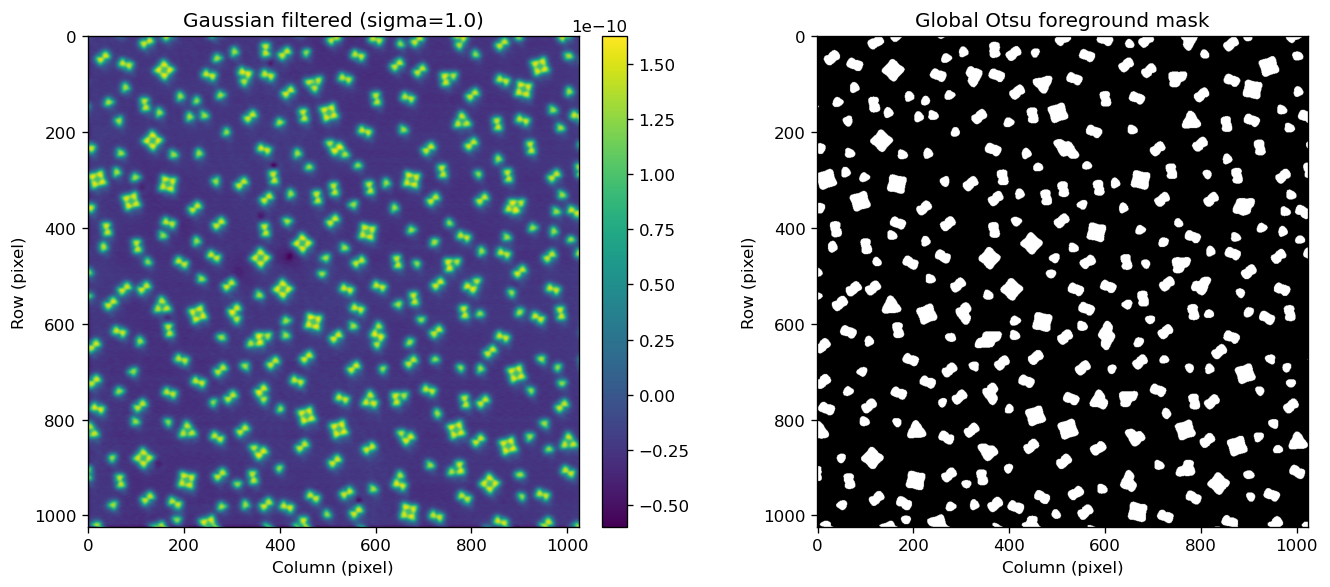

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

filtered_plot = axes[0].imshow(
    corrected_height, cmap="viridis", origin="upper"
)
axes[0].set_title(f"Gaussian filtered (sigma={GAUSSIAN_SIGMA})")
fig.colorbar(filtered_plot, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].imshow(otsu_mask, cmap="gray", origin="upper")
axes[1].set_title("Global Otsu foreground mask")

for ax in axes:
    ax.set_xlabel("Column (pixel)")
    ax.set_ylabel("Row (pixel)")

plt.tight_layout()
plt.show()

## 5. Morphological Cleaning

### 1. Closing

Closing consists of two operations:

$$
\text{Closing}=\text{Expansion}+\text{Contraction}
$$

#### 1.1 Expansion

The molecular region is expanded using a $3\times3$ matrix.

For example:

$$
\begin{bmatrix}
0&0&0\\
0&1&0\\
0&0&0
\end{bmatrix}
\quad\longrightarrow\quad
\begin{bmatrix}
0&1&0\\
1&1&1\\
0&1&0
\end{bmatrix}
$$

A one-dimensional example is:

```text
Before expansion:

[0 0 1 1 1 0 1 1 1 0 0]

After expansion:

[0 1 1 1 1 1 1 1 1 1 0]
```

The purpose of expansion is to fill small gaps in the image.

#### 1.2 Contraction

After expansion, the foreground region is contracted. If the required
neighbouring pixels around a centre pixel are not all equal to 1, the centre
pixel is changed to 0.

For example:

```text
Before contraction:

[0 1 1 1 1 1 1 1 1 1 0]

After contraction:

[0 0 1 1 1 1 1 1 1 0 0]
```

The purpose of contraction is to remove the additional foreground pixels at
the outer edges.

### 2. Hole Filling

If a region of 0-valued pixels is completely surrounded by pixels with the
value 1, the values inside that region are changed from 0 to 1.

For example:

$$
\begin{bmatrix}
1&1&1&1\\
1&0&0&1\\
1&1&0&1\\
1&0&0&1\\
1&1&1&1
\end{bmatrix}
\quad\longrightarrow\quad
\begin{bmatrix}
1&1&1&1\\
1&1&1&1\\
1&1&1&1\\
1&1&1&1\\
1&1&1&1
\end{bmatrix}
$$

### 3. Small-Object Removal

Connected regions of 1-valued pixels that contain fewer than 50 pixels are
removed and changed to 0. Regions containing at least 50 pixels are retained.

### 4. Border-Object Removal

After small-object removal, `clear_border` removes every complete connected
foreground region that touches the image boundary. These regions are likely
to be incomplete molecules because part of their structure lies outside the
scanned image. The entire connected region is removed rather than only its
border pixels.

### 5. Connected-Component Labelling

The remaining foreground pixels are grouped using 8-connectivity. Each
independent connected region receives one positive integer label, while the
background remains 0. These labels provide the candidate IDs used for the
object table, counting, bounding boxes, and later feature extraction.

In [8]:
closing_footprint = disk(CLOSING_RADIUS)
closed_mask = closing(otsu_mask, footprint=closing_footprint)
filled_mask = np.asarray(binary_fill_holes(closed_mask), dtype=bool)
size_filtered_mask = remove_small_objects(
    filled_mask,
    min_size=MIN_OBJECT_AREA,
    connectivity=CONNECTIVITY,
)
final_mask = clear_border(size_filtered_mask)
label_image = measure.label(final_mask, connectivity=CONNECTIVITY)

assert closed_mask.shape == raw_height.shape
assert filled_mask.shape == raw_height.shape
assert size_filtered_mask.shape == raw_height.shape
assert final_mask.shape == raw_height.shape
assert label_image.shape == raw_height.shape
assert final_mask.dtype == bool
assert label_image.min() == 0

positive_labels = np.unique(label_image[label_image > 0])
expected_labels = np.arange(1, int(label_image.max()) + 1)
assert np.array_equal(positive_labels, expected_labels)

print(f"Foreground after closing: {closed_mask.mean():.4%}")
print(f"Foreground after hole filling: {filled_mask.mean():.4%}")
print(
    "Foreground after small-object removal: "
    f"{size_filtered_mask.mean():.4%}"
)
print(f"Foreground after border-object removal: {final_mask.mean():.4%}")
print(f"Final foreground fraction: {final_mask.mean():.4%}")
print(f"Connected candidate regions: {int(label_image.max())}")

Foreground after closing: 16.2357%
Foreground after hole filling: 16.2357%
Foreground after small-object removal: 16.2248%
Foreground after border-object removal: 14.7470%
Final foreground fraction: 14.7470%
Connected candidate regions: 248


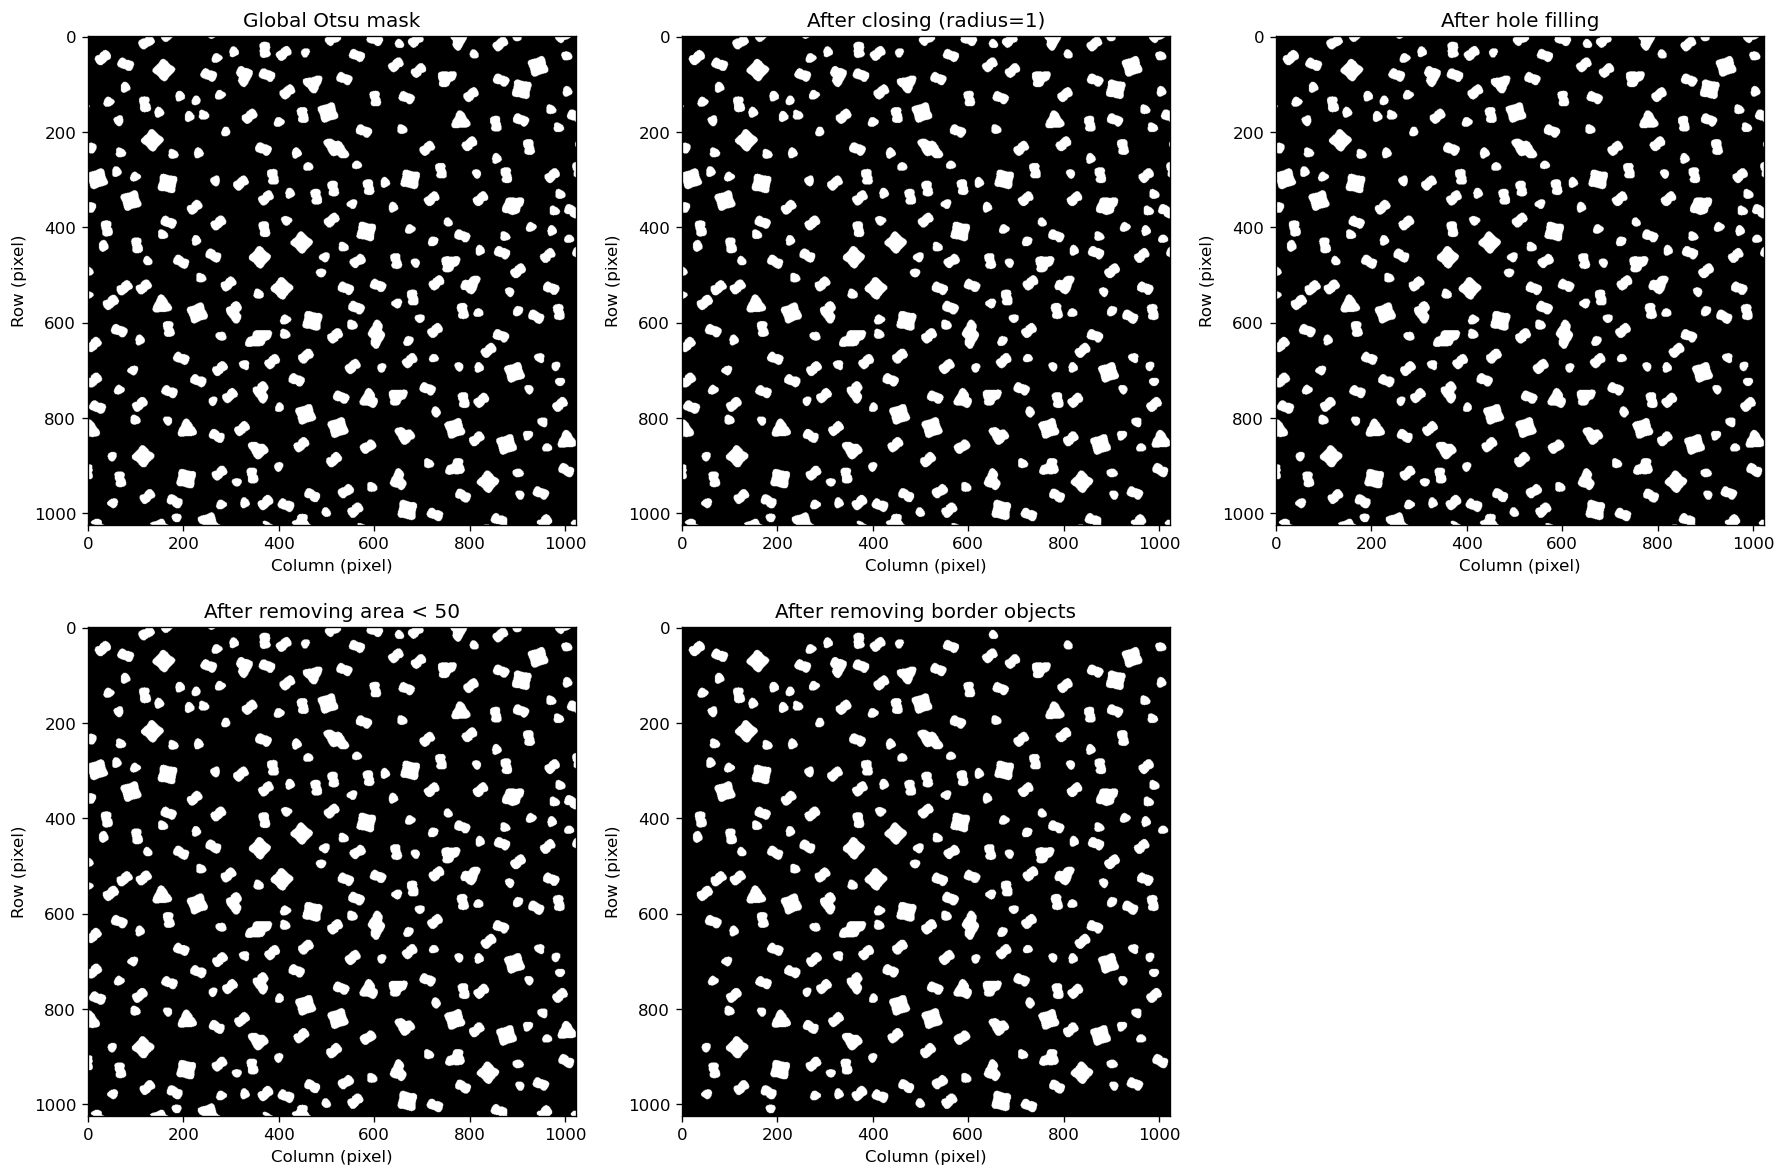

In [9]:
stage_masks = [
    otsu_mask,
    closed_mask,
    filled_mask,
    size_filtered_mask,
    final_mask,
]
stage_titles = [
    "Global Otsu mask",
    f"After closing (radius={CLOSING_RADIUS})",
    "After hole filling",
    f"After removing area < {MIN_OBJECT_AREA}",
    "After removing border objects",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax in axes.flat:
    ax.axis("off")

for ax, stage_mask, title in zip(axes.flat, stage_masks, stage_titles):
    ax.imshow(stage_mask, cmap="gray", origin="upper")
    ax.set_title(title)
    ax.set_xlabel("Column (pixel)")
    ax.set_ylabel("Row (pixel)")
    ax.axis("on")

plt.tight_layout()
plt.show()

## 6. Candidate-object table

`regionprops_table` converts the integer label image into a structured table with one row for each connected candidate region. Each column is obtained as follows:

- `object_id`: the unique positive integer assigned to the connected region in `label_image`. A value of 0 is reserved for the background.
- `area`: the number of foreground pixels belonging to the candidate region.
- `perimeter`: the estimated length of the candidate's outer boundary. Conceptually, each pixel is treated as a small square and the perimeter is found by counting how many pixel edges are exposed to the background. For example, a five-pixel cross has 12 exposed edges, while the six-pixel L-shaped region below has 14 exposed edges. `scikit-image` estimates the digital contour, so the reported value may be a decimal.

```text
Five-pixel cross:       Six-pixel L shape:

0 1 0                   1 1 0
1 1 1                   1 0 0
0 1 0                   1 1 1

Perimeter = 12          Perimeter = 14
```

- `centroid_row` and `centroid_col`: the average row and column coordinates of all pixels in the region, giving its centre position. Decimal values are expected because a centroid does not need to lie exactly at a pixel centre.
- `min_row`, `min_col`, `max_row`, and `max_col`: the limits of the smallest rectangular bounding box that contains the entire region. The maximum row and column are exclusive limits.
- `bbox_height` and `bbox_width`: the height and width of the bounding box, calculated from its row and column limits.
- `mean_intensity`: the average plane-corrected and Gaussian-filtered STM height across the region.
- `max_intensity`: the largest plane-corrected and Gaussian-filtered STM height inside the region.
- `quality_flag`: the current validation status of the candidate.

Every row is marked `candidate_unvalidated` because the detected candidates have not yet been matched against the independent manual annotations. Larger molecular assemblies can naturally have larger areas and perimeters, so no upper-size deletion is applied here.

In [10]:
properties = measure.regionprops_table(
    label_image,
    intensity_image=corrected_height,
    properties=(
        "label",
        "area",
        "perimeter",
        "centroid",
        "bbox",
        "mean_intensity",
        "max_intensity",
    ),
)

object_table = pd.DataFrame(properties).rename(
    columns={
        "label": "object_id",
        "centroid-0": "centroid_row",
        "centroid-1": "centroid_col",
        "bbox-0": "min_row",
        "bbox-1": "min_col",
        "bbox-2": "max_row",
        "bbox-3": "max_col",
    }
)
object_table["bbox_height"] = (
    object_table["max_row"] - object_table["min_row"]
)
object_table["bbox_width"] = (
    object_table["max_col"] - object_table["min_col"]
)
object_table["quality_flag"] = "candidate_unvalidated"

object_columns = [
    "object_id",
    "area",
    "perimeter",
    "centroid_row",
    "centroid_col",
    "min_row",
    "min_col",
    "max_row",
    "max_col",
    "bbox_height",
    "bbox_width",
    "mean_intensity",
    "max_intensity",
    "quality_flag",
]
object_table = (
    object_table[object_columns]
    .sort_values("object_id")
    .reset_index(drop=True)
)

assert len(object_table) == int(label_image.max())
assert np.array_equal(
    object_table["object_id"].to_numpy(),
    np.arange(1, int(label_image.max()) + 1),
)

print(f"Candidate-object table rows: {len(object_table)}")
if len(object_table):
    print(
        "Object area (pixels), min / median / max: "
        f"{object_table['area'].min():.0f} / "
        f"{object_table['area'].median():.1f} / "
        f"{object_table['area'].max():.0f}"
    )
display(object_table.head(10))

Candidate-object table rows: 248
Object area (pixels), min / median / max: 277 / 650.0 / 1414


,object_id,area,perimeter,centroid_row,centroid_col,min_row,min_col,max_row,max_col,bbox_height,bbox_width,mean_intensity,max_intensity,quality_flag
0,1,287.0,61.112698,15.742160,651.533101,6,642,25,662,19,20,7.766979e-11,1.256015e-10,candidate_unvalidated
1,2,679.0,101.597980,28.387334,369.979381,12,359,46,383,34,24,9.027616e-11,1.484145e-10,candidate_unvalidated
2,3,345.0,69.355339,32.727536,304.936232,21,296,45,316,24,20,8.114384e-11,1.349350e-10,candidate_unvalidated
3,4,657.0,100.225397,36.013699,409.409437,21,393,52,427,31,34,8.934099e-11,1.477637e-10,candidate_unvalidated
4,5,277.0,60.284271,34.436823,454.772563,26,446,45,465,19,19,7.725603e-11,1.253501e-10,candidate_unvalidated
5,6,633.0,99.497475,40.240126,562.807267,27,546,55,580,28,34,8.844360e-11,1.445719e-10,candidate_unvalidated
6,7,286.0,60.284271,37.520979,808.055944,28,799,47,818,19,19,7.825187e-11,1.265281e-10,candidate_unvalidated
7,8,697.0,102.811183,44.803443,30.767575,29,14,61,48,32,34,9.020450e-11,1.517317e-10,candidate_unvalidated
8,9,352.0,69.698485,41.241477,1001.937500,32,991,51,1015,19,24,8.153598e-11,1.359419e-10,candidate_unvalidated
9,10,344.0,67.941125,45.819767,269.107558,36,259,56,282,20,23,8.104391e-11,1.323412e-10,candidate_unvalidated


## 7. Detection overlay

This diagnostic overlays each candidate's bounding box, centroid, and `object_id` on the Gaussian-filtered height image. It is intended for identifying likely noise, merged regions, split regions, and edge cases before classification.

Dense text labels may require zooming into the saved PNG. They do not modify the label image or object table.

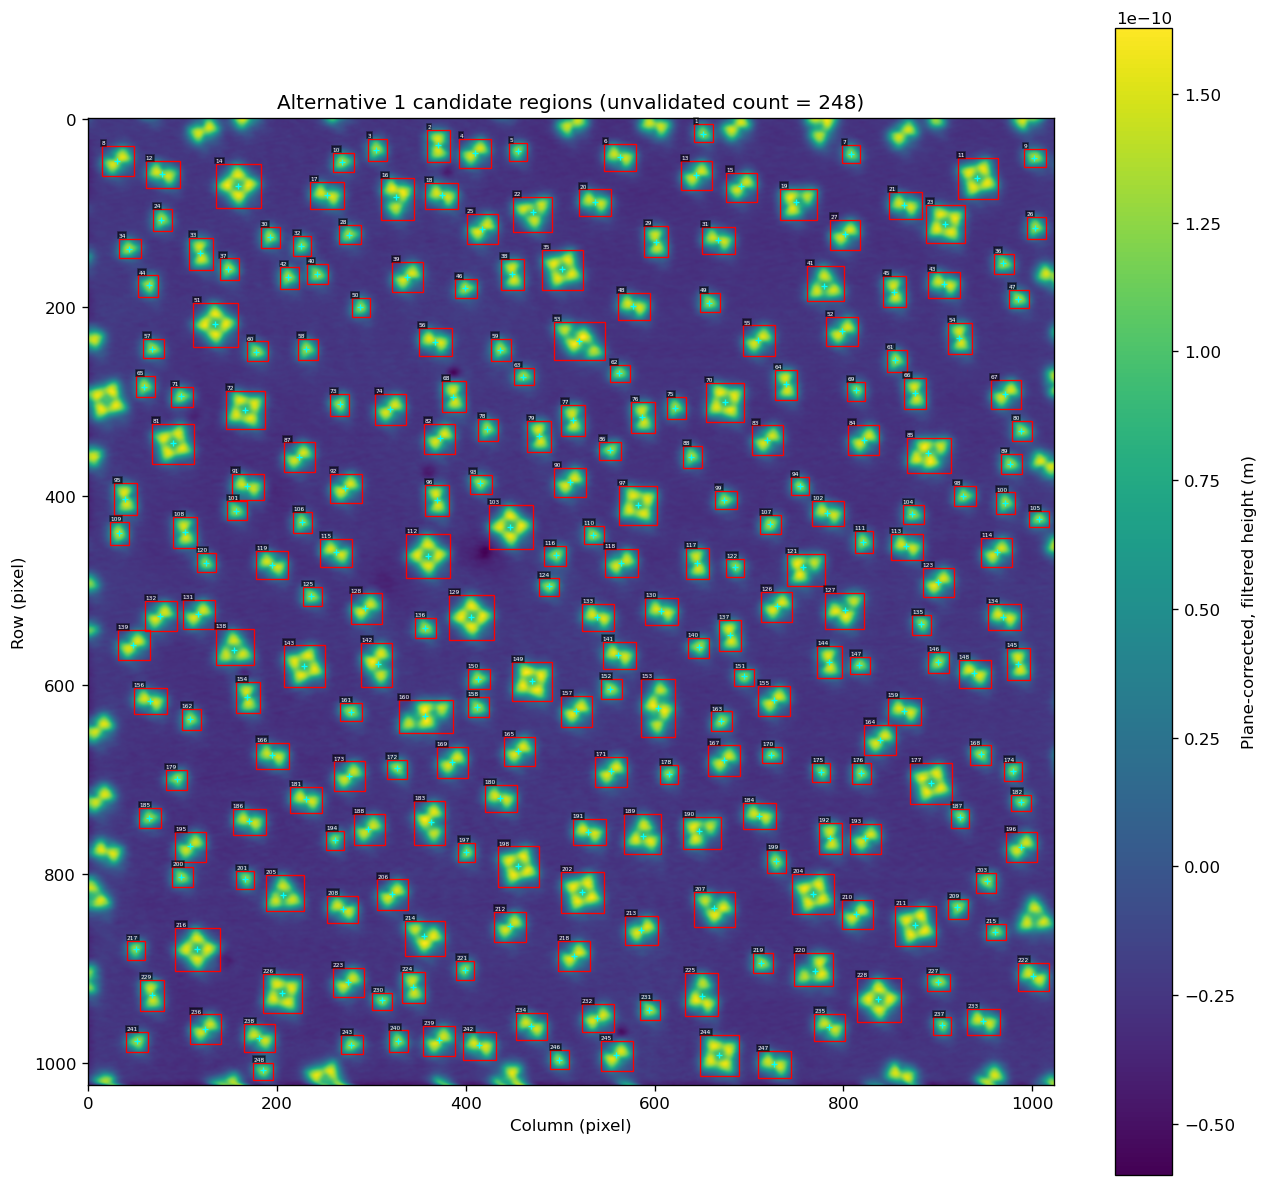

Saved: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P1/outputs/alternative_1_plane_fitting/detection_overlay.png


In [11]:
fig, ax = plt.subplots(figsize=(11, 10))
image = ax.imshow(corrected_height, cmap="viridis", origin="upper")

for row in object_table.itertuples(index=False):
    rectangle = mpatches.Rectangle(
        (row.min_col, row.min_row),
        row.max_col - row.min_col,
        row.max_row - row.min_row,
        fill=False,
        edgecolor="red",
        linewidth=0.8,
    )
    ax.add_patch(rectangle)
    ax.plot(
        row.centroid_col,
        row.centroid_row,
        marker="+",
        color="cyan",
        markersize=4,
        markeredgewidth=0.8,
    )
    ax.text(
        row.min_col,
        max(0, row.min_row - 2),
        str(int(row.object_id)),
        color="white",
        fontsize=3.5,
        bbox={"facecolor": "black", "alpha": 0.45, "pad": 0.2},
    )

ax.set_title(
    "Alternative 1 candidate regions "
    f"(unvalidated count = {len(object_table)})"
)
ax.set_xlabel("Column (pixel)")
ax.set_ylabel("Row (pixel)")
fig.colorbar(image, ax=ax, label="Plane-corrected, filtered height (m)")
plt.tight_layout()

overlay_path = OUTPUT_DIR / "detection_overlay.png"
fig.savefig(overlay_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {overlay_path}")

## 8. Candidate-object montage

The montage displays up to the first 64 candidates in `object_id` order. Each patch is cropped from the same filtered numerical height matrix, and pixels outside its own local label mask are hidden. This makes it easier to inspect whether objects resemble plausible molecular structures or segmentation failures.

The montage is a quality-control view only. It does not assign molecular classes.

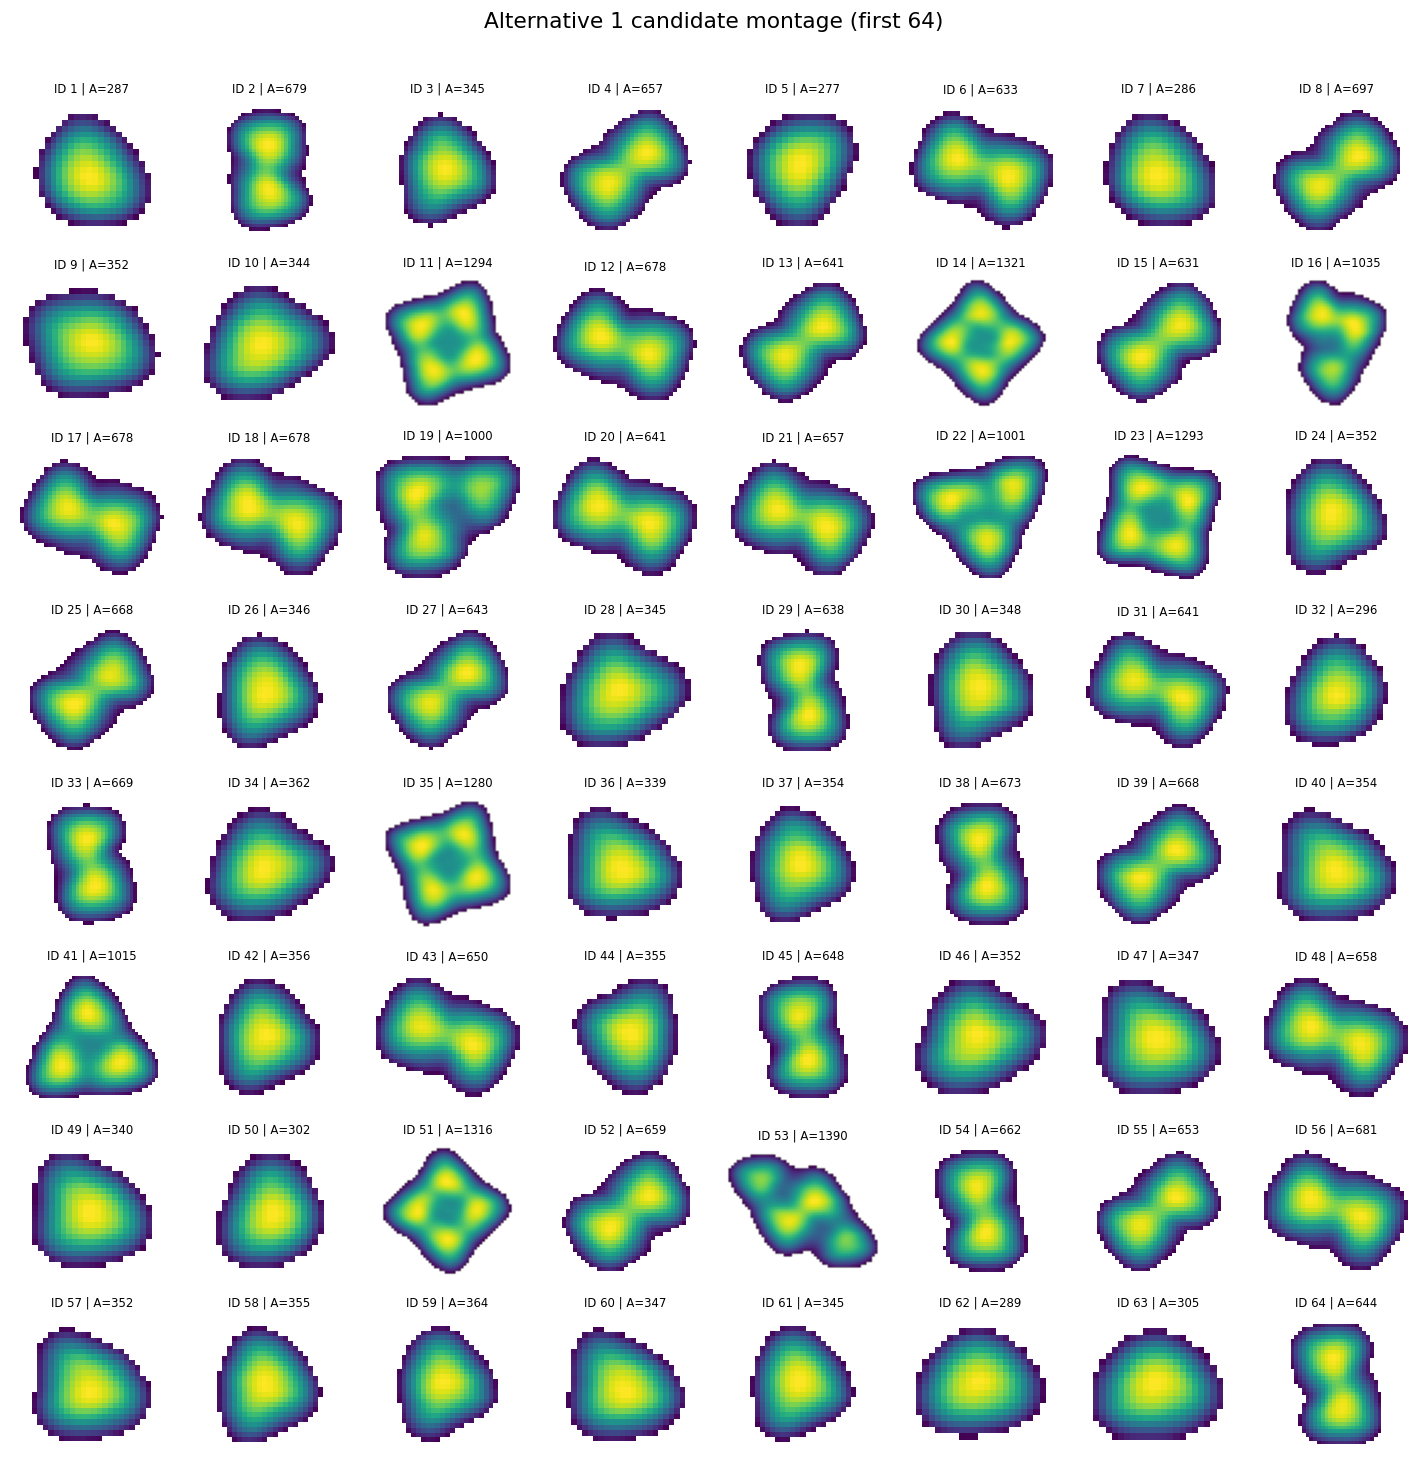

Saved: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P1/outputs/alternative_1_plane_fitting/object_montage.png


In [12]:
montage_count = min(len(object_table), 64)
montage_columns = 8
montage_rows = max(1, int(np.ceil(montage_count / montage_columns)))

fig, axes = plt.subplots(
    montage_rows,
    montage_columns,
    figsize=(12, 1.55 * montage_rows),
    squeeze=False,
)

for ax in axes.flat:
    ax.axis("off")

for ax, row in zip(axes.flat, object_table.head(montage_count).itertuples()):
    object_id = int(row.object_id)
    min_row = max(0, int(row.min_row) - 2)
    min_col = max(0, int(row.min_col) - 2)
    max_row = min(raw_height.shape[0], int(row.max_row) + 2)
    max_col = min(raw_height.shape[1], int(row.max_col) + 2)

    local_height = corrected_height[min_row:max_row, min_col:max_col]
    local_mask = (
        label_image[min_row:max_row, min_col:max_col] == object_id
    )
    masked_patch = np.where(local_mask, local_height, np.nan)

    ax.imshow(masked_patch, cmap="viridis", origin="upper")
    ax.set_title(
        f"ID {object_id} | A={int(row.area)}",
        fontsize=7,
    )
    ax.axis("off")

fig.suptitle(
    f"Alternative 1 candidate montage (first {montage_count})",
    fontsize=13,
)
plt.tight_layout(rect=(0, 0, 1, 0.97))

montage_path = OUTPUT_DIR / "object_montage.png"
fig.savefig(montage_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {montage_path}")

## 9. Export arrays, tables, and processing-stage figure

The exports preserve exactly what Alternative 1 produced:

- the plane-corrected and Gaussian-filtered numerical height matrix;
- the final Boolean segmentation mask;
- the integer connected-component label image;
- the candidate-object index;
- one table recording input metadata, parameters, coefficients, and descriptive outputs;
- figures for stage-by-stage and object-level inspection.

These files make the method reproducible and provide a common structure for later comparisons, without claiming that Alternative 1 is already the best method.

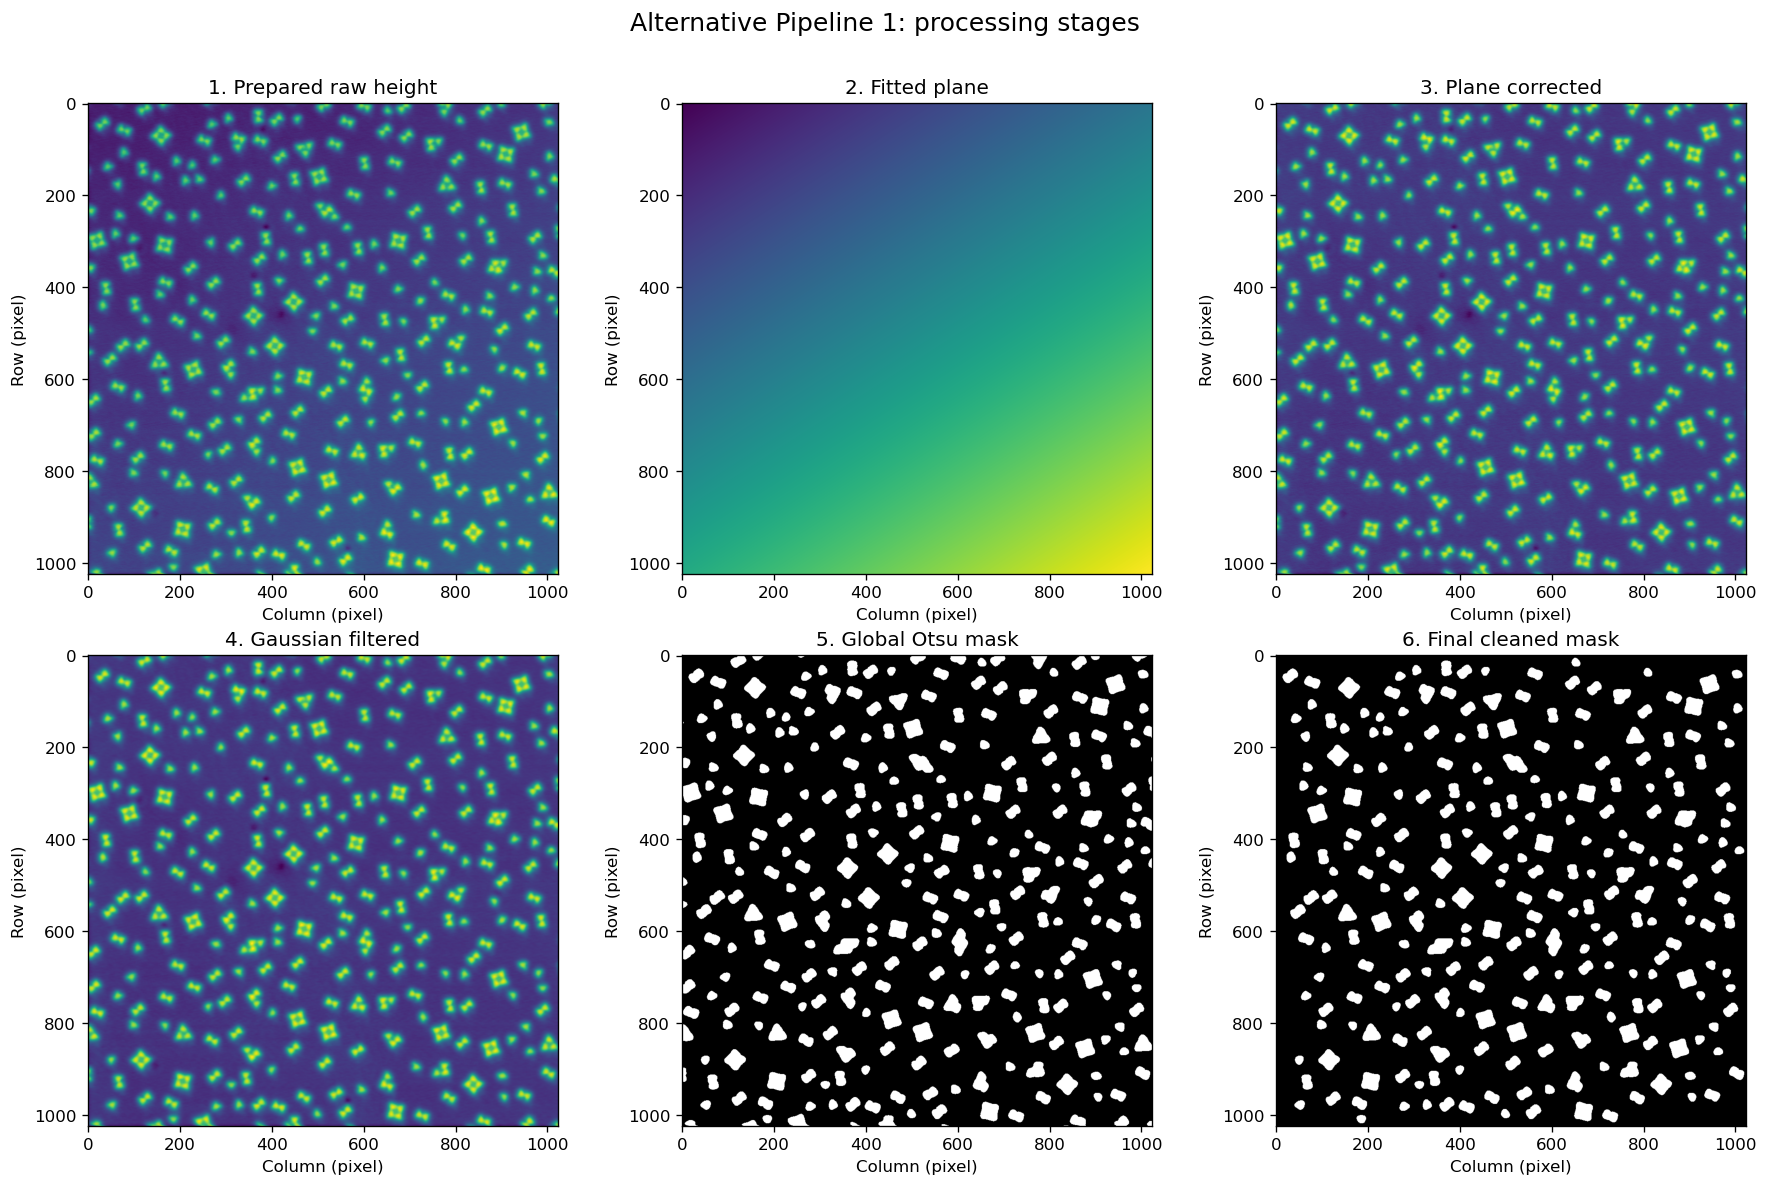

Exported Alternative 1 artifacts:
  corrected_height.npy: 8,388,736 bytes
  binary_mask.npy: 1,048,704 bytes
  label_image.npy: 4,194,432 bytes
  object_index.csv: 37,845 bytes
  processing_summary.csv: 750 bytes
  processing_stages.png: 2,458,618 bytes
  detection_overlay.png: 2,020,597 bytes
  object_montage.png: 298,749 bytes


In [13]:
corrected_height_path = OUTPUT_DIR / "corrected_height.npy"
binary_mask_path = OUTPUT_DIR / "binary_mask.npy"
label_image_path = OUTPUT_DIR / "label_image.npy"
object_index_path = OUTPUT_DIR / "object_index.csv"
summary_path = OUTPUT_DIR / "processing_summary.csv"
stages_path = OUTPUT_DIR / "processing_stages.png"

np.save(corrected_height_path, corrected_height)
np.save(binary_mask_path, final_mask.astype(bool))
np.save(label_image_path, label_image.astype(np.int32))
object_table.to_csv(object_index_path, index=False)

summary_rows = [
    ("input_file", str(DATA_FILE), ""),
    ("image_rows", raw_height.shape[0], "pixels"),
    ("image_columns", raw_height.shape[1], "pixels"),
    ("scan_direction", metadata["scan_direction"], ""),
    ("pixel_scale_x", metadata["pixel_scale_m"][0], "m/pixel"),
    ("pixel_scale_y", metadata["pixel_scale_m"][1], "m/pixel"),
    ("invalid_pixels_replaced", metadata["invalid_pixels_replaced"], "pixels"),
    ("plane_a", plane_a, "m/pixel-column"),
    ("plane_b", plane_b, "m/pixel-row"),
    ("plane_c", plane_c, "m"),
    ("gaussian_sigma", GAUSSIAN_SIGMA, "pixels"),
    ("otsu_threshold", otsu_threshold, "m"),
    ("closing_radius", CLOSING_RADIUS, "pixels"),
    ("minimum_object_area", MIN_OBJECT_AREA, "pixels"),
    ("border_object_removal", "clear_border", ""),
    ("connectivity", CONNECTIVITY, ""),
    ("final_foreground_fraction", float(final_mask.mean()), "fraction"),
    ("candidate_object_count", len(object_table), "objects"),
]
processing_summary = pd.DataFrame(
    summary_rows,
    columns=["parameter", "value", "unit"],
)
processing_summary.to_csv(summary_path, index=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
stage_data = [
    raw_height,
    fitted_plane,
    plane_corrected,
    corrected_height,
    otsu_mask,
    final_mask,
]
stage_titles = [
    "1. Prepared raw height",
    "2. Fitted plane",
    "3. Plane corrected",
    "4. Gaussian filtered",
    "5. Global Otsu mask",
    "6. Final cleaned mask",
]
stage_cmaps = ["viridis", "viridis", "viridis", "viridis", "gray", "gray"]

for ax, data, title, cmap in zip(
    axes.flat, stage_data, stage_titles, stage_cmaps
):
    ax.imshow(data, cmap=cmap, origin="upper")
    ax.set_title(title)
    ax.set_xlabel("Column (pixel)")
    ax.set_ylabel("Row (pixel)")

fig.suptitle("Alternative Pipeline 1: processing stages", fontsize=15)
plt.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(stages_path, dpi=180, bbox_inches="tight")
plt.show()

print("Exported Alternative 1 artifacts:")
for path in [
    corrected_height_path,
    binary_mask_path,
    label_image_path,
    object_index_path,
    summary_path,
    stages_path,
    overlay_path,
    montage_path,
]:
    print(f"  {path.name}: {path.stat().st_size:,} bytes")

## 10. End-to-end validation

This final Cell reloads the exported files rather than trusting only the in-memory variables. It checks shape, finite values, Boolean mask values, consecutive labels, table-to-label alignment, and non-empty figures.

Passing these checks demonstrates that the implementation is internally consistent and reproducible. It does **not** establish detection accuracy. Accuracy can only be evaluated later by matching these candidates against an independent manual reference.

In [14]:
reloaded_height = np.load(corrected_height_path)
reloaded_mask = np.load(binary_mask_path)
reloaded_labels = np.load(label_image_path)
reloaded_objects = pd.read_csv(object_index_path)
reloaded_summary = pd.read_csv(summary_path)

assert reloaded_height.shape == raw_height.shape == (1024, 1024)
assert reloaded_mask.shape == raw_height.shape
assert reloaded_labels.shape == raw_height.shape
assert np.isfinite(reloaded_height).all()
assert reloaded_mask.dtype == bool
assert set(np.unique(reloaded_mask)).issubset({False, True})

reloaded_positive_labels = np.unique(
    reloaded_labels[reloaded_labels > 0]
)
assert np.array_equal(
    reloaded_positive_labels,
    np.arange(1, int(reloaded_labels.max()) + 1),
)
assert len(reloaded_objects) == int(reloaded_labels.max())
assert np.array_equal(
    reloaded_objects["object_id"].to_numpy(),
    np.arange(1, int(reloaded_labels.max()) + 1),
)
assert len(reloaded_summary) == 18

expected_files = [
    corrected_height_path,
    binary_mask_path,
    label_image_path,
    object_index_path,
    summary_path,
    stages_path,
    overlay_path,
    montage_path,
]
assert all(path.is_file() and path.stat().st_size > 0 for path in expected_files)

print("All Alternative 1 validation checks passed.")
print(f"Final unvalidated candidate count: {len(reloaded_objects)}")
print(f"Output directory: {OUTPUT_DIR}")
print(
    "Evidence boundary: successful execution and internally consistent "
    "outputs do not establish detection accuracy."
)

All Alternative 1 validation checks passed.
Final unvalidated candidate count: 248
Output directory: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P1/outputs/alternative_1_plane_fitting
Evidence boundary: successful execution and internally consistent outputs do not establish detection accuracy.
